In [115]:
from ESM_ACDC_Forcing import year_sum, the_model

import matplotlib.pyplot as plt
import numpy as np
import importlib
from tqdm import tqdm
import cmocean as cm
import scipy as sp

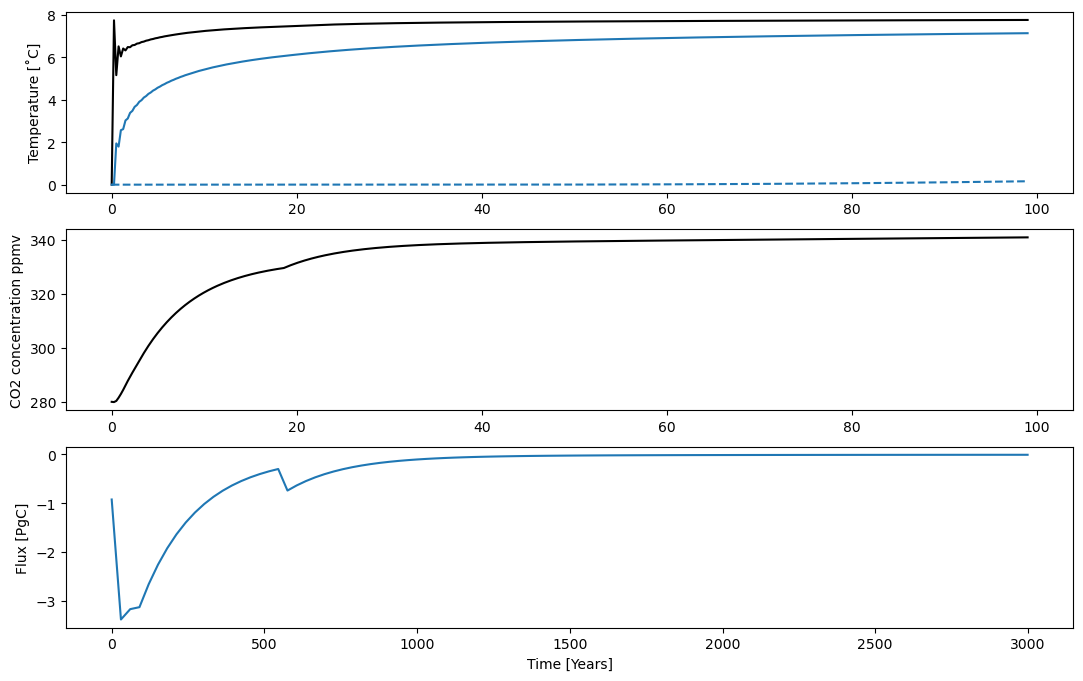

In [98]:
import sys, importlib
importlib.reload(sys.modules['ESM_ACDC_Forcing'])
from ESM_ACDC_Forcing import year_sum, the_model


# test plot for rate constants

time,T_A,c_A,T_O,pco2,DIC,F_AS,GPP,W_X,F_rad = the_model(nyear = 1e2, F_ext = lambda t: 10)
Ocean_Flux = year_sum(F_AS)/(1e12)
Land_Flux = year_sum(GPP)/(4e12)
Flux_time = np.linspace(0,2999,len(Land_Flux))


plt.figure(figsize=(13,8))
plt.subplot(3,1,1)
plt.plot(time,T_A,'k')
plt.plot(time,T_O[:,0],'C0')
plt.plot(time,T_O[:,-1],'C0--')
plt.ylabel('Temperature [˚C]')
#plt.ylim(0,10)

plt.subplot(3,1,2)
plt.plot(time,c_A,'k')
#plt.plot(time[:-1],pco2,'C0')
plt.ylabel('CO2 concentration ppmv')
# plt.ylim(280,1300)
#plt.plot(time,W_X)
#plt.ylabel('Soil Water [-]')
#plt.xlim(0,500)
plt.subplot(3,1,3)
plt.plot(Flux_time,Land_Flux)
#plt.plot(Flux_time,Ocean_Flux)
#plt.plot(time,DIC[:,0],'C0')
#plt.plot(time,DIC[:,-1],'C0--')
#plt.ylabel('DIC [umol/kg]')
plt.ylabel('Flux [PgC]')
#plt.ylim(2100,2200)
plt.xlabel('Time [Years]')
plt.show()

In [99]:
import sys, importlib
importlib.reload(sys.modules['ESM_ACDC_Forcing'])
from ESM_ACDC_Forcing import year_sum, the_model

F_values = np.linspace(-20,20,30)
T_values = np.zeros_like(F_values)
C_values = np.zeros_like(F_values)
F_rad_values = np.zeros_like(F_values)

for i in tqdm(range(len(F_values))):
    F = F_values[i]
    F_ = lambda t: F
    time,T_A,c_A,T_O,pco2,DIC,F_AS,GPP,W_X,F_rad = the_model(nyear = 5e3, F_ext = F_)

    T_values[i] = T_A[-1]
    C_values[i] = c_A[-1]
    F_rad_values[i] = F_rad[-1]


100%|██████████| 30/30 [02:17<00:00,  4.58s/it]


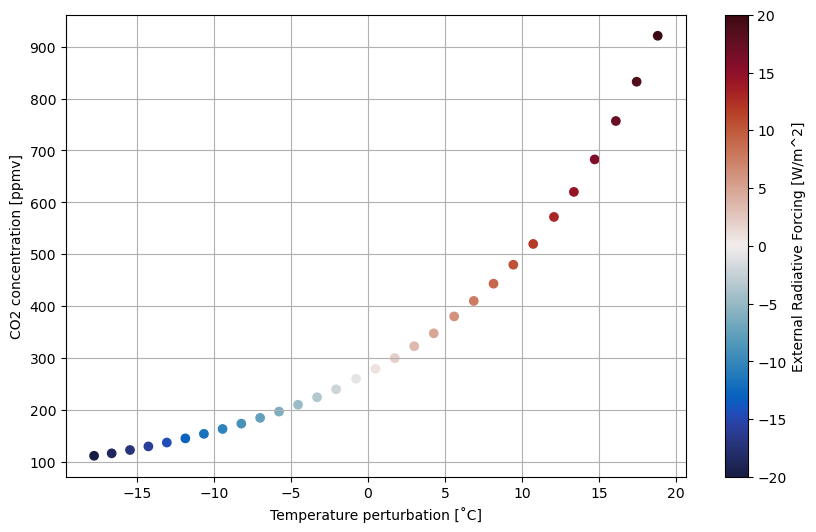

In [106]:
plt.figure(figsize=(10,6))

p=plt.scatter(T_values,C_values,c=F_values,cmap = cm.cm.balance)
plt.colorbar(p, label='External Radiative Forcing [W/m^2]')
plt.xlabel('Temperature perturbation [˚C]')
plt.ylabel('CO2 concentration [ppmv]')
plt.grid()

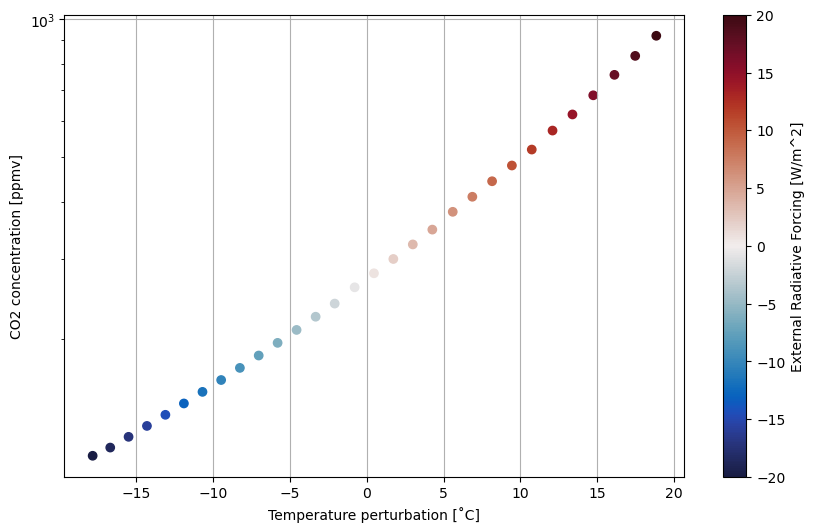

In [111]:
plt.figure(figsize=(10,6))

p=plt.scatter(T_values,C_values,c=F_values,cmap = cm.cm.balance)
plt.gca().set_yscale('log')
plt.colorbar(p, label='External Radiative Forcing [W/m^2]')
plt.xlabel('Temperature perturbation [˚C]')
plt.ylabel('CO2 concentration [ppmv]')
plt.grid()

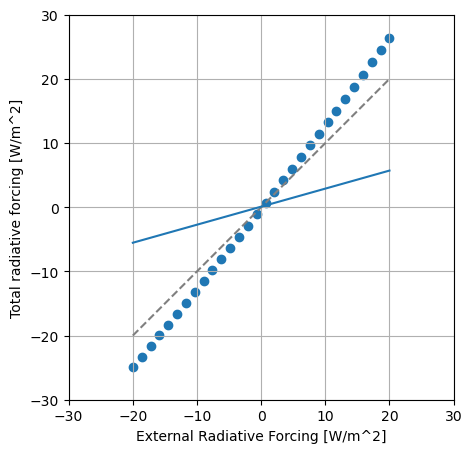

In [ ]:
plt.figure(figsize=(10,5))
plt.gca().set_aspect('equal', adjustable='box')
F_values_filled = np.linspace(-20,20,100)

p=plt.scatter(F_values,F_rad_values)
plt.plot(F_values_filled,F_values_filled,linestyle = '--',color = 'gray',label = '1:1 line')
plt.xlim([-30,30])
plt.ylim([-30,30])



plt.xlabel('External Radiative Forcing [W/m^2]')
plt.ylabel('Total radiative forcing [W/m^2]')
plt.grid()

In [130]:
m,b,r,pval,_, = sp.stats.linregress(F_values,F_rad_values - F_values)

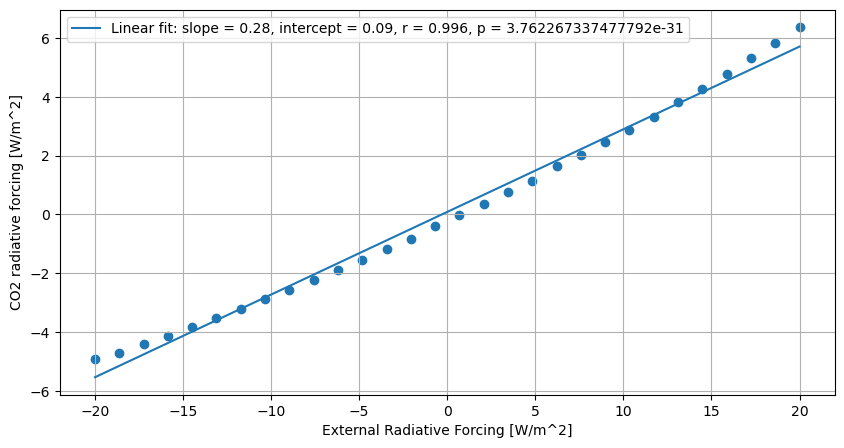

In [135]:
plt.figure(figsize=(10,5))

p=plt.scatter(F_values,F_rad_values - F_values)

plt.xlabel('External Radiative Forcing [W/m^2]')
plt.ylabel('CO2 radiative forcing [W/m^2]')
plt.plot(F_values_filled,m*F_values_filled + b,linestyle = '-',color = 'C0',label = f'Linear fit: slope = {m:.2f}, intercept = {b:.2f}, r = {r:.3f}, p = {pval}')
plt.legend()
plt.grid()